In [1]:
import scanpy as sc
import numpy as np
import h5py
import json
import matplotlib.pyplot as plt
import torch
import argparse
import json
import pickle

import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC/")


from src.tf2rNet.models import Sei, MotifNet
from src.tf2rNet.utils import *

from src.deepSCENIC import deepSCENIC
import src.utils as utils

from captum.attr import DeepLiftShap, InputXGradient
from enformer_pytorch import Enformer

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (5.1.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "
2023-09-14 15:42:37.135185: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-14 15:42:37.293559: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=

### Load tf2rNet model

In [2]:
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines/'

parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

# Select device 'cpu' or 'cuda' (gpu)
opt.device = 'cuda'
if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

In [3]:
# Compile model and initialize data loaders
model = deepSCENIC(opt)
dataloader, _, TFs_idx, r2g_dist_coo, seq_dataloader, _  = model.init_data()

dir exist
reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12200
    var: 'n_cells'
    uns: 'log1p'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 222530
False


In [4]:
# Initialize TF2rNet model
tf2r_model_path = RES_PATH + '/model_tf2r.pth'
tf2r_func_enc_model_path = RES_PATH + '/model_tf2r_encoder.pth'

with open(opt.ppms_file, 'rb') as f:
    PPMs = pickle.load(f)
model_dict_tf2rNet = torch.load(tf2r_model_path,  map_location=torch.device(opt.device))['model_state_dict']
if not opt.enformer_embs_file:
    model_dict_tf2r_func_enc = torch.load(tf2r_func_enc_model_path,  map_location=torch.device(opt.device))['model_state_dict']
    # Initialize tf2rNet cnn
    tf2rNet_func_encoder = Sei(sequence_length=opt.seq_len).float().to(opt.device)
    tf2rNet = MotifNet(PPMs, model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, explain=False, dev=opt.device).float().to(opt.device)
    tf2rNet_func_encoder.load_state_dict(model_dict_tf2r_func_enc)
    tf2rNet.load_state_dict(model_dict_tf2rNet)
    tf2rNet_func_encoder.eval()
else:
    tf2rNet = MotifNet(PPMs, model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, explain=False, dev=opt.device).float().to(opt.device)
    tf2rNet.load_state_dict(model_dict_tf2rNet)
    # Initialize Enformer model
    tf2rNet_func_encoder = Enformer.from_pretrained('EleutherAI/enformer-official-rough', target_length=5, dropout_rate = 0).to(opt.device)

In [38]:
# Define the concatenated model with a custom forward method
class ConcatModel(torch.nn.Module):
    def __init__(self, models):
        super(ConcatModel, self).__init__()
        self.models = torch.nn.ModuleList(models)

    def forward(self, seq, motif=False):
        if motif==False:
            seq = torch.unsqueeze(seq, dim=0)
            for model in self.models:
                if isinstance(model, Enformer):
                    x = model(seq, return_only_embeddings=True)
                elif isinstance(model, MotifNet):                 
                    x = model(emb=x, motif=motif)
                    x = torch.unsqueeze(x, dim=0)
                else:
                    x = model(seq)
            return x
        else:
            seq = torch.unsqueeze(seq, dim=0)
            for model in self.models:
                if isinstance(model, MotifNet):
                    x = model(seq=seq, motif=motif, explain=True)
            return x

model = ConcatModel([tf2rNet_func_encoder, tf2rNet]).to(opt.device)   
model.eval();     

In [8]:
# Load gene expression data
DATA_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'
ad_rna = sc.read(opt.data_rna_file)

# Write regions to explain to bed file
from src.utils import format_region_to_bed
reg = 'chr6:395297-397411' #IRF4

output_file = open(DATA_PATH + 'enhancer.bed', 'w')
[format_region_to_bed(r, output_file) for r in [reg]]
output_file.close()

In [9]:
# Initialize sequence dataset
from enformer_pytorch import GenomeIntervalDataset

ds = GenomeIntervalDataset(
    bed_file = DATA_PATH + 'enhancer.bed',   # bed file - columns 0, 1, 2 must be <chromosome>, <start position>, <end position>
    fasta_file = opt.fasta, # path to fasta file
    return_seq_indices = False, # return nucleotide indices (ACGTN) or one hot encodings
    shift_augs = (0, 0),    # random shift augmentations from -2 to +2 basepairs
    rc_aug = False, # use reverse complement augmentation with 50% probability
    context_length = 640, #sequence length to extract
    return_augs = False  # return the augmentation meta data
)

In [39]:
# Initialize the explanation methods
ixg = InputXGradient(model)

In [11]:
samples_1hot = ds[0].to('cuda')[2114//2-320:2114//2+320] # resize sequence to 640 bp
samples_1hot.requires_grad_()
samples_1hot.requires_grad

True

In [12]:
# Select the TF for which to explain the input sequence
TF = 'SOX10'
TF_idx = np.where(ad_rna[:, TFs_idx].var_names==TF)[0][0] # get TF index

In [21]:
# predict motif scores
with torch.no_grad():
    pred_mtf = torch.squeeze(model(samples_1hot, motif=True))
pred_mtf[TF_idx]

tensor(1., device='cuda:0')

In [15]:
# Predict functional scores
with torch.no_grad():
    pred_ctx = torch.squeeze(model(samples_1hot, motif=False))
pred_ctx[TF_idx]

tensor(3.4183, device='cuda:0')

In [22]:
# Sort combined predictions
torch.sort(pred_mtf * pred_ctx)

torch.return_types.sort(
values=tensor([-3.6274, -3.4067, -3.1537,  ...,  2.8037,  2.9801,  3.4183],
       device='cuda:0'),
indices=tensor([772, 729, 434,  ..., 452, 672, 718], device='cuda:0'))

In [40]:
# Compute attribution scores with motif and functional head
attr_mtf = ixg.attribute(samples_1hot, target=int(TF_idx), additional_forward_args=(True,))
attr_mtf = attr_mtf.cpu().detach().numpy()
attr_ctx = ixg.attribute(samples_1hot, target=int(TF_idx), additional_forward_args=(False,))
attr_ctx = attr_ctx.cpu().detach().numpy()

In [41]:
# #### PROBABLY NOT NEEDED ####
# seq_len = 640
# attr_mtf = attr_mtf[seq_len//2-250:seq_len//2+250, :]
# attr_ctx = attr_ctx[seq_len//2-250:seq_len//2+250, :]
# samples_500bp = samples_1hot[seq_len//2-250:seq_len//2+250, :]

640it [00:48, 13.22it/s]


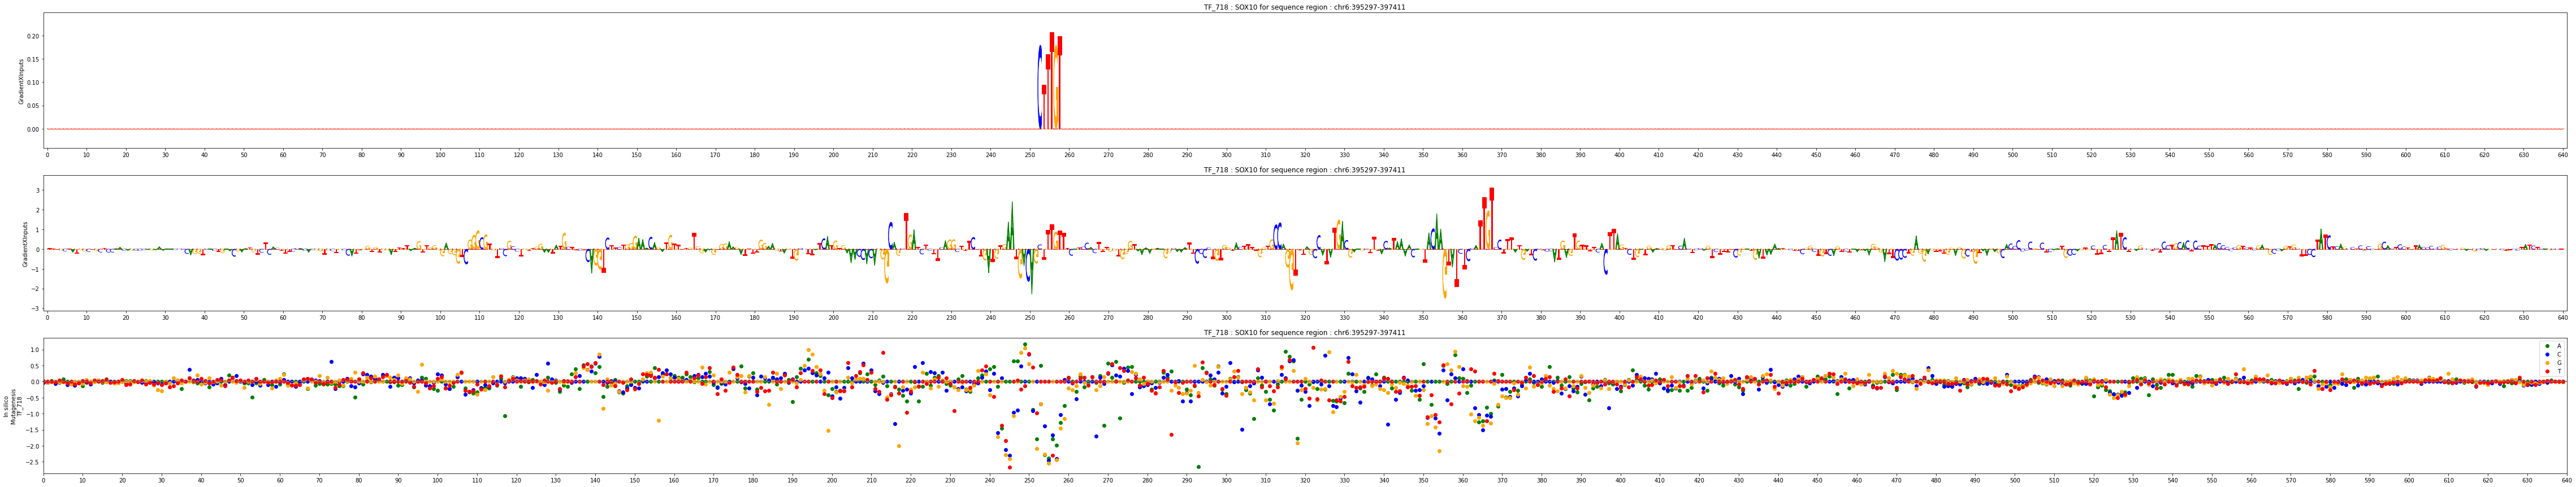

In [46]:
ntrack = 3
fig = plt.figure(figsize=(80,ntrack*5))
axes = [None, None, None]
_, axes[0] = utils.plot_weights((attr_mtf)*samples_1hot.cpu().detach().numpy(),
                      fig, ntrack, 1, 1,
                      title="TF_" + str(TF_idx) + ' : ' + TF + ' for sequence region : ' + reg,
                      subticks_frequency=10, ylab="GradientXInputs")

_, axes[1] = utils.plot_weights((attr_ctx)*samples_1hot.cpu().detach().numpy(),
                      fig, ntrack, 1, 2,
                      title="TF_" + str(TF_idx) + ' : ' + TF + ' for sequence region : ' + reg,
                      subticks_frequency=10, ylab="GradientXInputs")

# Plot in silico mutagenesis for the selected topic
axes[2] = utils.plot_mutagenesis_givenax(model=model, fig=fig, ntrack=ntrack, track_no=3, 
                                seq_onehot=samples_1hot.to('cpu'), num_classes=TFs_idx.shape[0], 
                                TF = TF_idx, TF_name=TF, region_id=reg, seq_len=640, mutated_seq_len=640)
